In [1]:
import sys
sys.path.append('/Users/mariana/Documents/col/lts4/survan')
sys.path.append('/Users/mariana/Documents/col/lts4/tdsurv/lib')


from tdsurv import CoxPH
from tdsurv import concordance_index as tdsurv_ci
from deep_lambda_cox import DeepLambdaSA

from utils import concordance_index, unroll_time, unroll, score
import yaml
import jax
import jax.numpy as jnp
import haiku as hk
import numpy as np
import matplotlib.pyplot as plt

# Random Walk 

In [2]:
from scipy.special import expit as sigmoid
from utils import get_targets_and_masks

In [3]:
# Borrowed from tdsurv (https://github.com/spotify-research/tdsurv/blob/main/notebooks/random-walk-final.ipynb)
def make_generator(mat, sigma, sigma0, thetas, bias, rng):
    """Sample from a Gauss-Markov process.
    
    Initial state:
    
        x_0 = noise(sigma0)
    
    Transition dynamics:
    
        x_nxt = np.dot(mat, x) + noise(sigma)
        
    Churn probability:
    
        p = sigmoid(np.dot(x, thetas) + bias)
    """
    n_dims = mat.shape[0]
    def gen(n_samples, horizon):
        seqs = np.zeros((n_samples, horizon + 1, n_dims + 1))
        ts = np.zeros(n_samples, dtype=int)
        cs = np.zeros(n_samples, dtype=bool)
        for i in range(n_samples):
            seqs[i, 0] = np.append(sigma0 * rng.normal(size=n_dims), 1)
            ts[i] = 1
            for j in range(0, horizon):
                p = sigmoid(np.dot(seqs[i, j, :-1], thetas) + bias)
                if rng.uniform() < p:
                    break
                ts[i] += 1
                seqs[i, j + 1] = np.append(
                    np.dot(mat, seqs[i, j, :-1]) + sigma * rng.normal(size=n_dims),
                    1,
                )
            if ts[i] > horizon:
                ts[i] = horizon
                cs[i] = True
        tgt_lm, hws_lm, mask_lm = get_targets_and_masks(seqs, ts, cs, landmark=True)
        return (seqs.astype(np.float32), ts, cs, tgt_lm, hws_lm, mask_lm)
    return gen

In [17]:
rng = np.random.default_rng(seed=0)
n_dims = 20
horizon = 50
d = n_dims + 1

# Churn parameters.
thetas = rng.normal(size=n_dims)
bias = -4

# Transition dynamics.
mat = 1.0 * np.eye(n_dims)
sigma = 0.5
sigma0 = 1.0 # Affect results quite a lot

gen = make_generator(mat, sigma, sigma0, thetas, bias, rng)
seqs_v, ts_v, cs_v, y_v, hws_v, m_v = gen(n_samples=1000, horizon=horizon)

In [18]:
H = horizon + 1

In [19]:
cs_v.sum()/len(cs_v)

0.204

In [20]:
# N-fold cross-validation
n_folds = 30
data = list()
for i in range(n_folds):
    data.append(gen(n_samples=300, horizon=horizon))

In [21]:
# "dummy" config file
config_path = '../configs/config_rw.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [22]:
# tau is the target learning rate. For example tau = 0.01 implies the target network is updated every 100 iterations.
# I need to get the number of total iterations that correspond to exactly 10 updates of the target network for each value of tau.
# For example, for tau=0.01, I'll need 1000 iterations to get 10 updates of the target network.

def get_n_epochs(tau, n_updates=10):
    return int(1/tau * n_updates)

In [23]:
%%time

# sizes = [10, 30, 50, 100]  # Test size is 20% of dataset 
# taus = [0.01, 0.1, 0.25, 0.5, 0.75, 1.0]
taus = [.01, .05, 0.1, .25, .5, 1.0]
size = 50

rw_ci_dtd = np.zeros((n_folds, len(taus)))
rw_ibs_dtd = np.zeros((n_folds, len(taus)))

l2 = 1e-4
lambda_ = 0.0
p_vars = []

for i, tau in enumerate(taus):
    var_hs = []

    for fold in range(n_folds):
        seqs_t, ts_t, cs_t, y_t, hws_t, m_t = data[fold]
        
        print(".", end="")
        seqs_, ts_, cs_ = unroll(seqs_t[:size], ts_t[:size], cs_t[:size])

        # Deep TD
        config['axis'] = 2
        config['weight_decay'] = 1e-4
        config['target_lr'] = tau
        config['dataset_kwargs']['horizon'] = H
        config['arch']['arch_kwargs']['seq_len'] = H
        model = DeepLambdaSA(config, seed=42)
        model.lambda_ = lambda_

        train_gen, test_gen = model.get_train_test(test_size=size)
        train_gen.X = seqs_t[:size]
        train_gen.ts = ts_t[:size]
        train_gen.cs = cs_t[:size]
        train_gen.y = y_t[:size]
        train_gen.mask = m_t[:size]
        train_gen.h_ws = hws_t[:size]

        _ = model.train(train_gen)
        surv = model.survival_curve(seqs_v)
        scores = model.scores(seqs_v, q=0.5)
        rw_ci_dtd[fold, i] = concordance_index(scores, ts_v, cs_v)
        rw_ibs_dtd[fold, i] = model.integrated_brier_score(surv[:,0], ts_v, cs_v)

        logits = model.forward(model.state.params, seqs_v)
        hs = jax.nn.sigmoid(logits) * hws_v
        var_hs.append(hs)

    var_hs = jnp.stack(var_hs)
    p_bar = var_hs.mean(0)[hws_v]
    p_std = var_hs.std(0)[hws_v]
    p_var = p_std/(p_bar*(1-p_bar))

    p_vars.append(p_var)

    print()

..............................
..............................
..............................
..............................
..............................
..............................
CPU times: user 33min 56s, sys: 6min 46s, total: 40min 42s
Wall time: 24min 44s


In [24]:
n_folds

30

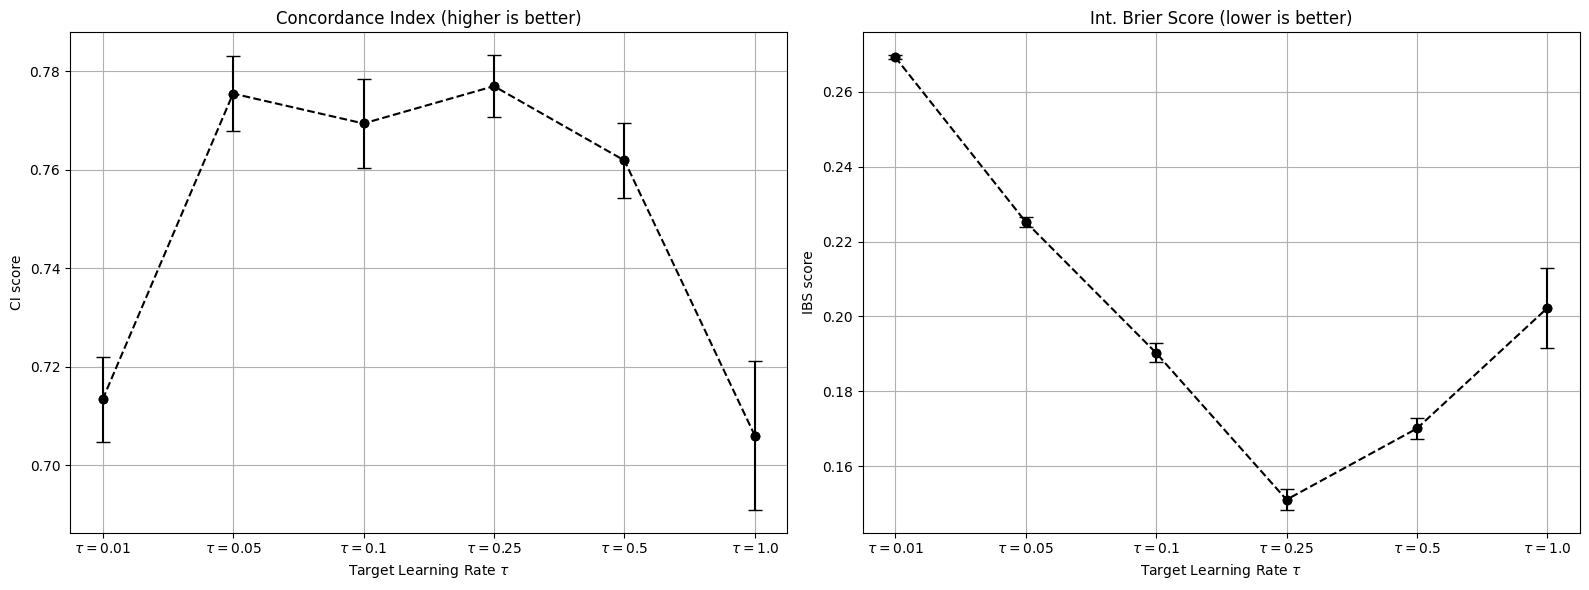

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data (replace this with your actual data)
# rw_ci_dtd = np.random.rand(5, 7)  # Example data of shape (5, 7)
arrs = [rw_ci_dtd, rw_ibs_dtd]
titles = ['Concordance Index (higher is better)', 'Int. Brier Score (lower is better)']
labels = ['CI score', 'IBS score']

# Lambda values
lambda_values = taus

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # Create subplots with 1 row and 2 columns

for i, ax in enumerate(axs):
    # Plot error bars with caps
    arr = arrs[i]
    # Calculate mean and standard deviation
    means = np.mean(arr, axis=0)
    stds = np.std(arr, axis=0)/np.sqrt(n_folds)

    for j in range(arr.shape[1]):
        ax.errorbar(np.arange(len(lambda_values))[j], means[j], yerr=stds[j], fmt='o', color='black', capsize=5)

    # Plot mean dots connected by dashed line
    ax.plot(np.arange(len(lambda_values)), means, linestyle='--', marker='o', color='black')

    # Add labels and title
    ax.set_xlabel('Target Learning Rate $\\tau$')
    ax.set_ylabel(labels[i])
    ax.set_title(titles[i])

    # Set xticks
    lambda_labels = [f"$\\tau={val}$" for val in lambda_values]
    ax.set_xticks(np.arange(len(lambda_values)))
    ax.set_xticklabels(lambda_labels)

    ax.grid(True)

plt.tight_layout()
plt.savefig(f'ci_ibs_ablation_h{horizon}_rw.pdf', bbox_inches='tight')
plt.show()


In [16]:
rw_ci_dtd.mean(0)
rw_ci_dtd.std(0)/np.sqrt(n_folds)

for i, tau in enumerate(taus):
    print(f"Tau={tau}")
    print(f"Mean CI score: {rw_ci_dtd.mean(0)[i]}+/-{rw_ci_dtd.std(0)[i]/np.sqrt(n_folds)}")
    print(f"Mean IBS score: {rw_ibs_dtd.mean(0)[i]}+/-{rw_ibs_dtd.std(0)[i]/np.sqrt(n_folds)}")


Tau=0.01
Mean CI score: 0.7690341237988655+/-0.006198627687746879
Mean IBS score: 0.22502549128963853+/-0.0011330581119119026
Tau=0.05
Mean CI score: 0.7829867408893864+/-0.008028969037483012
Mean IBS score: 0.18636110437015446+/-0.0029748713976834565
Tau=0.1
Mean CI score: 0.8097787950706851+/-0.006203458901922204
Mean IBS score: 0.13864601828914272+/-0.0026899987034905565
Tau=0.25
Mean CI score: 0.8008210164782156+/-0.006657705154404999
Mean IBS score: 0.14105279393642922+/-0.0029787421218389117
Tau=0.5
Mean CI score: 0.7970846357684046+/-0.006071223128715933
Mean IBS score: 0.14749497603247247+/-0.003086764419430172
Tau=1.0
Mean CI score: 0.7685760204016001+/-0.01447494647008448
Mean IBS score: 0.1689786539957722+/-0.005239696447522039


In [15]:
from scipy.stats import ttest_rel
alpha = 0.05
mean_ci = rw_ci_dtd.mean(axis=0)
stderr_ci = rw_ci_dtd.std(axis=0, ddof=1) / np.sqrt(n_folds)
best_idx = int(np.argmax(mean_ci))
best_tau = taus[best_idx]
print(f"Best tau by mean CI: {best_tau} (mean={mean_ci[best_idx]:.4f}+/-{stderr_ci[best_idx]:.4f})")
print(f"Paired t-tests against tau={best_tau} at alpha={alpha}")
significant_better = []
significant_worse = []
for j, tau in enumerate(taus):
    if j == best_idx:
        continue
    t_stat, p_val = ttest_rel(rw_ci_dtd[:, best_idx], rw_ci_dtd[:, j])
    direction = '>' if t_stat > 0 else '<'
    significant = p_val < alpha
    outcome = 'significant' if significant else 'not significant'
    print(f"tau={best_tau} vs tau={tau}: t={t_stat:.3f}, p={p_val:.4f} ({outcome}, best tau {direction} tau)")
    if significant:
        if t_stat > 0:
            significant_better.append(tau)
        else:
            significant_worse.append(tau)
if significant_worse:
    print(f"tau={best_tau} loses to: {significant_worse} at alpha={alpha}")
elif significant_better:
    print(f"tau={best_tau} is significantly better than: {significant_better} at alpha={alpha}")
else:
    print(f"No significant differences detected for tau={best_tau} at alpha={alpha}.")


Best tau by mean CI: 0.1 (mean=0.8098+/-0.0063)
Paired t-tests against tau=0.1 at alpha=0.05
tau=0.1 vs tau=0.01: t=4.427, p=0.0001 (significant, best tau > tau)
tau=0.1 vs tau=0.05: t=2.732, p=0.0106 (significant, best tau > tau)
tau=0.1 vs tau=0.25: t=0.984, p=0.3333 (not significant, best tau > tau)
tau=0.1 vs tau=0.5: t=1.516, p=0.1403 (not significant, best tau > tau)
tau=0.1 vs tau=1.0: t=2.407, p=0.0227 (significant, best tau > tau)
tau=0.1 is significantly better than: [0.01, 0.05, 1.0] at alpha=0.05


In [25]:
from scipy.stats import ttest_rel
alpha = 0.05
mean_ci = rw_ci_dtd.mean(axis=0)
stderr_ci = rw_ci_dtd.std(axis=0) / np.sqrt(rw_ci_dtd.shape[0])
best_idx = int(np.argmax(mean_ci))
best_tau = taus[best_idx]
print(f"Best tau by mean CI: {best_tau} (mean={mean_ci[best_idx]:.4f}+/-{stderr_ci[best_idx]:.4f})")
print(f"Paired t-tests against tau={best_tau} at alpha={alpha}")
significant_better = []
significant_worse = []
for j, tau in enumerate(taus):
    if j == best_idx:
        continue
    t_stat, p_val = ttest_rel(rw_ci_dtd[:, best_idx], rw_ci_dtd[:, j])
    direction = '>' if t_stat > 0 else '<'
    significant = p_val < alpha
    outcome = 'significant' if significant else 'not significant'
    print(f"tau={best_tau} vs tau={tau}: t={t_stat:.3f}, p={p_val:.4f} ({outcome}, best tau {direction} tau)")
    if significant:
        if t_stat > 0:
            significant_better.append(tau)
        else:
            significant_worse.append(tau)
if significant_worse:
    print(f"tau={best_tau} loses to: {significant_worse} at alpha={alpha}")
elif significant_better:
    print(f"tau={best_tau} is significantly better than: {significant_better} at alpha={alpha}")
else:
    print(f"No significant differences detected for tau={best_tau} at alpha={alpha}.")


Best tau by mean CI: 0.05 (mean=0.7887+/-0.0173)
Paired t-tests against tau=0.05 at alpha=0.05
tau=0.05 vs tau=0.01: t=2.414, p=0.0732 (not significant, best tau > tau)
tau=0.05 vs tau=0.1: t=0.689, p=0.5288 (not significant, best tau > tau)
tau=0.05 vs tau=0.25: t=0.082, p=0.9385 (not significant, best tau > tau)
tau=0.05 vs tau=0.5: t=1.573, p=0.1908 (not significant, best tau > tau)
tau=0.05 vs tau=1.0: t=1.737, p=0.1574 (not significant, best tau > tau)
No significant differences detected for tau=0.05 at alpha=0.05.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample data (replace this with your actual data)
# ll = [p_vars[i] for i, lambda_ in enumerate(lambdas) if lambda_ != .5]  #Removing lambda=0.5
ll = p_vars

# Lambda values
lambda_values = taus

# Plotting
fig, axs = plt.subplots(2, 3, figsize=(16, 8), sharex=True)  # Create subplots with 2 rows and 4 columns

for i, ax in enumerate(axs.flat):
    if i < len(ll):
        sns.histplot(ll[i], ax=ax, color='skyblue')  # Make histogram instead of KDE plot
        ax.axvline(0, color='gray', linestyle='--')  # Add a gray dashed line at x=0
        ax.axvline(np.mean(ll[i]), color='red')  # Add a red vertical line at the mean
        ax.set_title(f'$\\tau= {lambda_values[i]}$')
        # Add labels selectively
        if i == 0 or i == 3:  # First column
            ax.set_ylabel('Density')  # Change ylabel to 'Count' for histograms
        else:
            ax.set_ylabel('')  # Change ylabel to 'Count' for histograms
        # if i < 1:
        #     ax.set_xlabel('')
        # else:  # Second row
        ax.set_xlabel('Variability of estimations $\\delta$')
    else:
        ax.axis('off')  # Hide empty subplots

plt.tight_layout()
plt.savefig(f'variability_ablation_tau_h_{horizon}.png', bbox_inches='tight')
plt.show()


In [ ]:
# rw_ibs_dtd

In [ ]:
# aux1 = p_vars[0]
# aux1[aux1<0]

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Sample data (replace this with your actual data)
# # ll = [np.random.normal(loc=i, scale=1, size=100) for i in range(7)]  # Example data
# ll = p_vars

# # Lambda values
# lambda_values = taus

# # Plotting
# fig, axs = plt.subplots(2, 4, figsize=(16, 8))  # Create subplots with 2 rows and 4 columns

# for i, ax in enumerate(axs.flat):
#     if i < len(ll):
#         sns.kdeplot(ll[i], ax=ax, color='skyblue')
#         ax.axvline(0, color='gray', linestyle='--')  # Add a gray dashed line at x=0
#         ax.axvline(np.mean(ll[i]), color='red')  # Add a red vertical line at the mean
#         ax.set_title(f'$\\tau = {lambda_values[i]}$')
#         # Add labels selectively
#         if i % 4 == 0:  # First column
#             ax.set_ylabel('Density')
#         if i >= 3:  # Second row
#             ax.set_xlabel('Variability of estimations')
#     else:
#         ax.axis('off')  # Hide empty subplots

# plt.tight_layout()
# # plt.savefig('variability_ablation_h30.pdf', bbox_inches='tight')
# plt.show()


In [ ]:
# 

In [ ]:
# data[data<0]

In [ ]:
# # Plot histogram
# sns.histplot(data, kde=False, color='skyblue', bins=30)

# # Add labels and title
# plt.xlabel('Value')
# plt.ylabel('Frequency')
# plt.title('Histogram')

# plt.show()

In [ ]:
# 